In [ ]:
# 1. Read your dataset, print parts of your data (head and tail)
# Load the dataset
import pandas as pd
import numpy as np
from tabulate import tabulate#Library to organize the the output

# Load the dataset
url = "https://www.openml.org/data/get_csv/31/dataset_31_car.arff"  # This might need to be replaced with a CSV version
df = pd.read_csv(url)

print("Head:")
print(tabulate(df.head(), headers='keys', tablefmt='pretty'))

print("\nTail: ")
print(tabulate(df.tail(), headers='keys', tablefmt='pretty'))


Head:
+---+-----------------+----------+----------------------------------+---------------------+---------------+--------------------+------------+------------------------+----------------------+---------------+-----------------+---------------------+-----+---------------------+------------+------------------+----------------------+----------------+---------------+----------------+-------+
|   | checking_status | duration |          credit_history          |       purpose       | credit_amount |   savings_status   | employment | installment_commitment |   personal_status    | other_parties | residence_since | property_magnitude  | age | other_payment_plans |  housing   | existing_credits |         job          | num_dependents | own_telephone | foreign_worker | class |
+---+-----------------+----------+----------------------------------+---------------------+---------------+--------------------+------------+------------------------+----------------------+---------------+---------------

In [ ]:
# 2. Provide description of the dataset and comment on the following:
# Basic description
print("="*40)
print("Dataset Basic Description")
print("="*40)
print(df.describe(include='all'))

# a. Number of instances
print("\n" + "="*40)
print("Number of Instances")
print("="*40)
print(f"Total Rows: {df.shape[0]}")

# b. Missing values
print("\n" + "="*40)
print("Missing Values")
print("="*40)
print(df.isnull().sum())

# c. Representations of missing values
print("\n" + "="*40)
print("Other Representations of Missing Values ('?', 'unknown')")
print("="*40)
print(df.isin(['?', 'unknown']).sum())

# d. Data types
print("\n" + "="*40)
print("Data Types")
print("="*40)
print(df.dtypes)

# e. Categorical attributes
print("\n" + "="*40)
print("Categorical Attributes & Unique Values")
print("="*40)
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n▶ {col} ({df[col].nunique()} unique):")
    print(df[col].unique())


Dataset Basic Description
       checking_status     duration   credit_history   purpose  credit_amount  \
count             1000  1000.000000             1000      1000    1000.000000   
unique               4          NaN                5        10            NaN   
top      'no checking'          NaN  'existing paid'  radio/tv            NaN   
freq               394          NaN              530       280            NaN   
mean               NaN    20.903000              NaN       NaN    3271.258000   
std                NaN    12.058814              NaN       NaN    2822.736876   
min                NaN     4.000000              NaN       NaN     250.000000   
25%                NaN    12.000000              NaN       NaN    1365.500000   
50%                NaN    18.000000              NaN       NaN    2319.500000   
75%                NaN    24.000000              NaN       NaN    3972.250000   
max                NaN    72.000000              NaN       NaN   18424.000000   

 

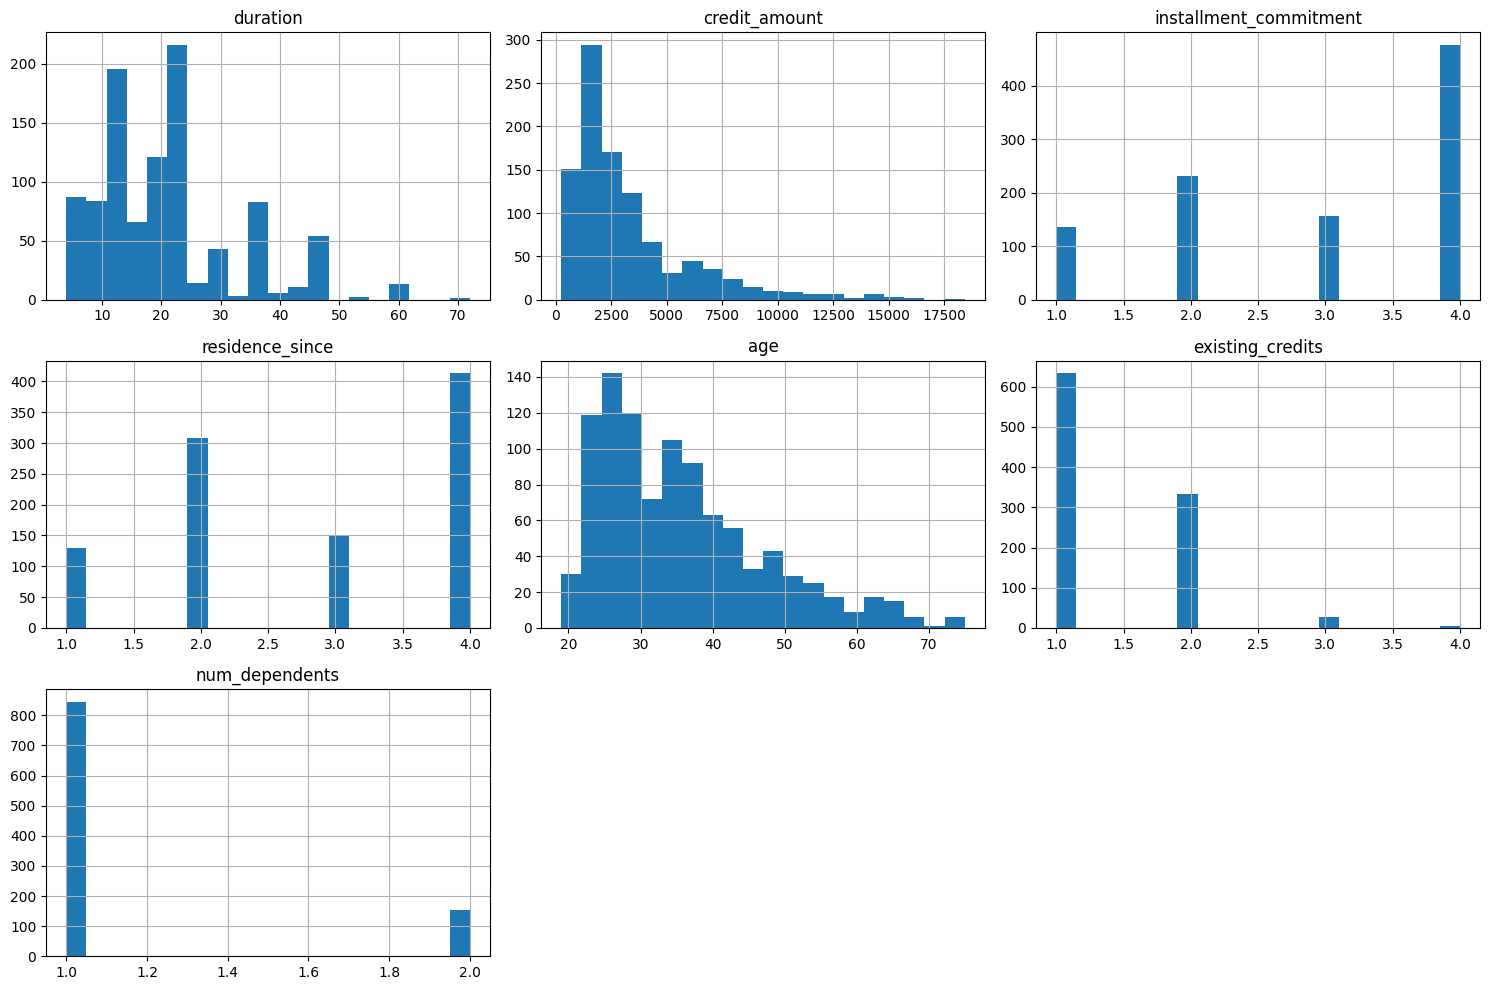

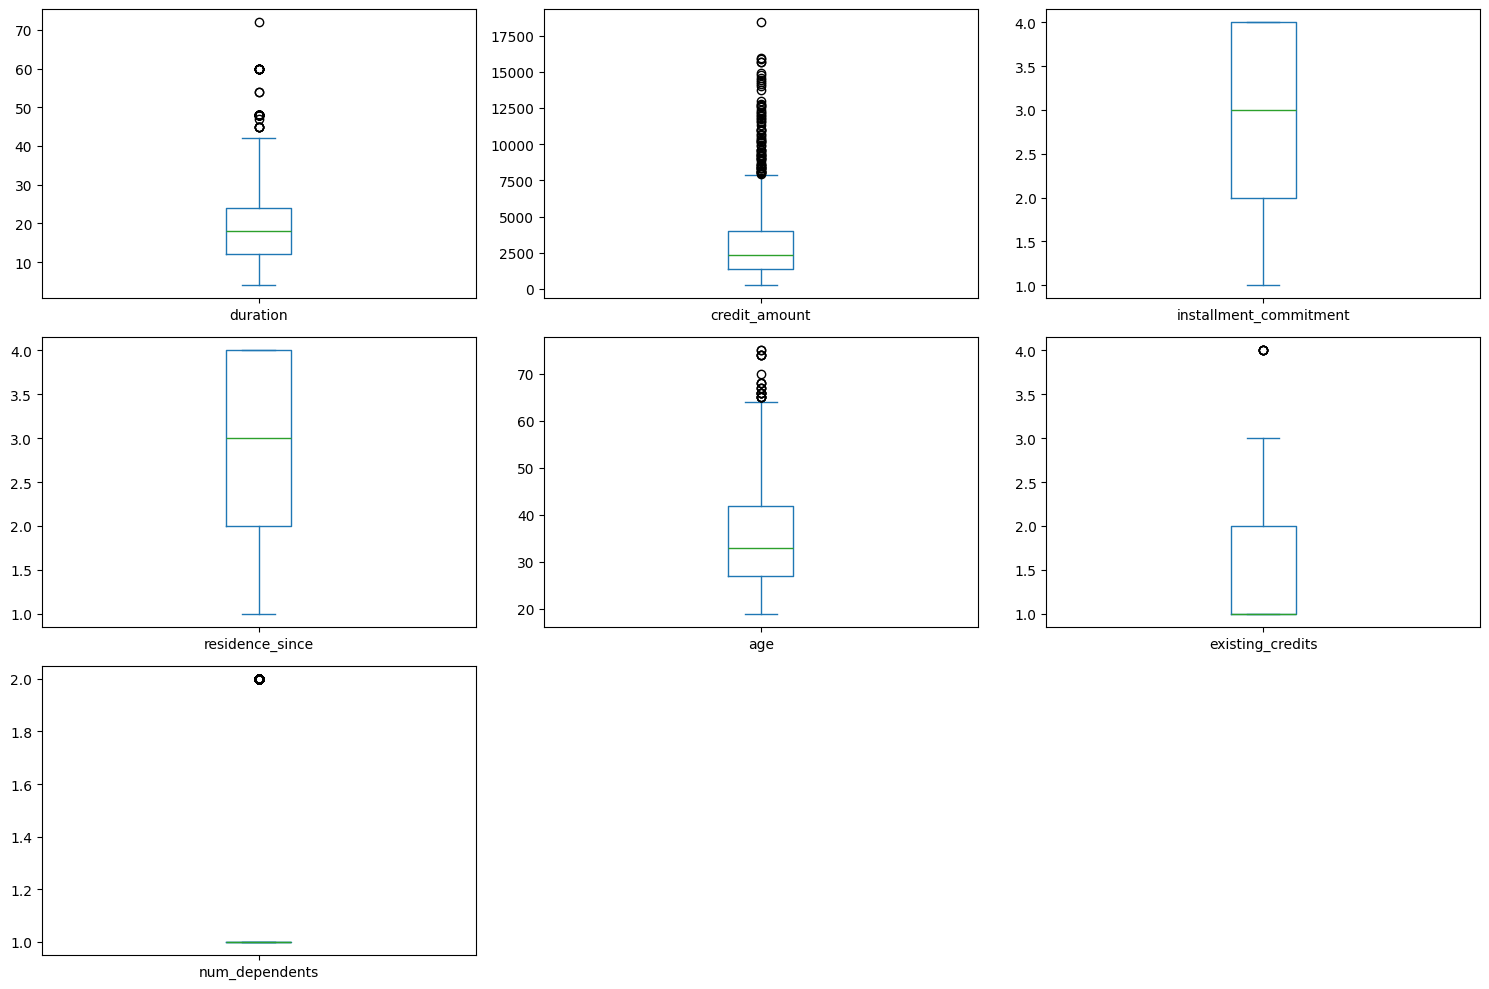

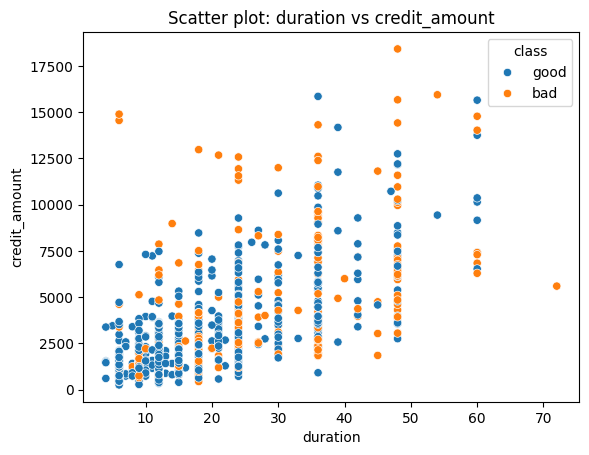

In [ ]:
#3. Make the suitable visualization of your dataset (histogram, boxplot, and scatter plot)

import matplotlib.pyplot as plt
import seaborn as sns

# Histograms
df.hist(bins=20, figsize=(15,10))
plt.tight_layout()
plt.show()

# Boxplots for numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols].plot(kind='box', subplots=True, layout=(3,3), figsize=(15,10))
plt.tight_layout()
plt.show()

# Scatter plot (make sure you have at least 2 numeric columns)
if len(numeric_cols) >= 2:
    sns.scatterplot(data=df, x=numeric_cols[0], y=numeric_cols[1], hue=categorical_cols[-1])
    plt.title(f"Scatter plot: {numeric_cols[0]} vs {numeric_cols[1]}")
    plt.show()



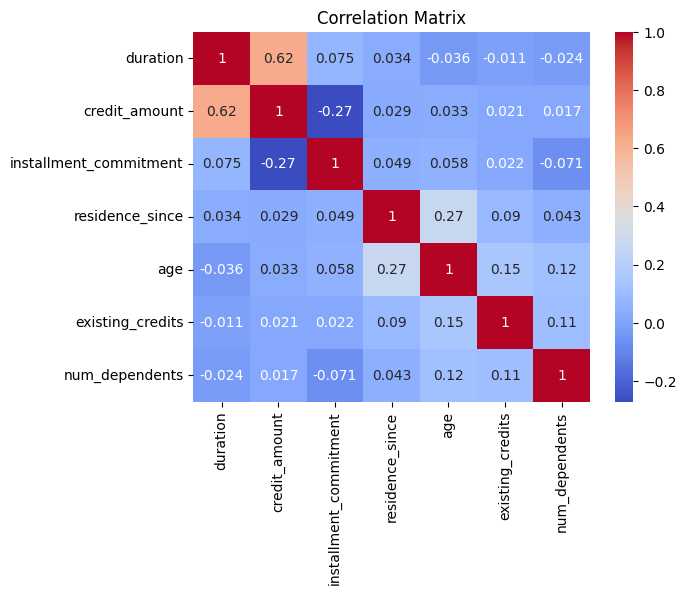

In [ ]:
#4. Study the correlation between the attributes.
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [ ]:
#5. Models Training include:
#i. Algorithms that you have used.
#ii. Cross validation
# Step 1: Imports and Setup
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Step 2: Encode categorical variables
df_clean = df.replace('?', np.nan).dropna().copy()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le

# Step 3: Prepare features and target
X = df_clean.drop(columns=['class'])
y = df_clean['class']

# Step 4: Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6: Define selected models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

# Step 7: Cross-validation
cv_results = {}

print("="*50)
print("Model Performance (Cross-Validation)")
print("="*50)

for name, model in models.items():
    X_used = X_train_scaled if name in ["Logistic Regression", "KNN"] else X_train
    scores = cross_val_score(model, X_used, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

# Optional: nicely formatted summary DataFrame
summary_df = pd.DataFrame({
    "Model": list(cv_results.keys()),
    "Mean Accuracy": [scores.mean() for scores in cv_results.values()],
    "Std Dev": [scores.std() for scores in cv_results.values()]
}).sort_values(by="Mean Accuracy", ascending=False)



Model Performance (Cross-Validation)
Logistic Regression: 0.7137 ± 0.0235
Random Forest: 0.7500 ± 0.0288
KNN: 0.7150 ± 0.0229


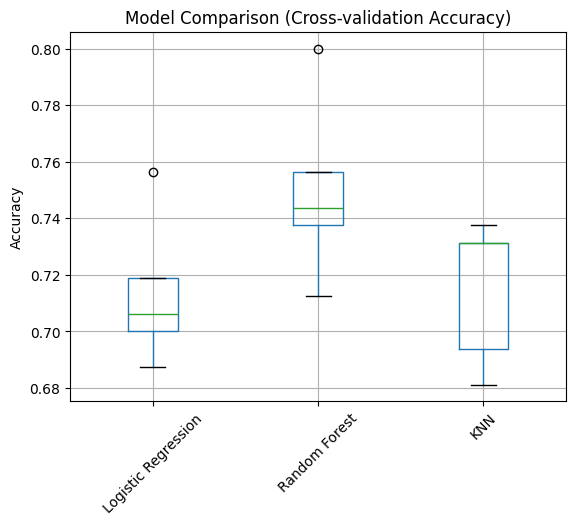


Selected Model: Random Forest
Model Selection: The Random Forest model achieved the highest mean accuracy (0.7537) among all the models evaluated.


In [ ]:
#6. Models evaluation include:
#i. Performance metrics you have used.
#ii. Comparison of models’ performance using table or plots.
#iii. Which model you select and why.

import matplotlib.pyplot as plt

# Plotting model comparison
results_df = pd.DataFrame(cv_results)
results_df.boxplot()
plt.title("Model Comparison (Cross-validation Accuracy)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

# Final selection
best_model = max(cv_results, key=lambda k: np.mean(cv_results[k]))
print(f"\nSelected Model: {best_model}")
print("Model Selection: The Random Forest model achieved the highest mean accuracy (0.7537) among all the models evaluated.")
